In [1]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import os

In [2]:
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
path = "./dataset_aug"
train_dir = os.path.join(path, "train")

# test_dir = os.path.join(path, "test")
test_dir = "./dataset"

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True, num_workers=2,pin_memory=True, persistent_workers=True)


print(train_dataset.classes)

['Not_Shubh', 'Shubh']


In [4]:
path = "./dataset_aug"

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Load all images
dataset = datasets.ImageFolder(path, transform=transform)

# 80-20 train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

print(dataset.classes)   # ['Not_Shubh', 'Shubh']
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

['Not_Shubh', 'Shubh']
Train samples: 2016
Test samples: 504


In [5]:
# .to(device)
# used for using gpu


class imgClDG(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.norm1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.norm2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.norm3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3)
        # self.norm4 = nn.BatchNorm2d(128)
        # self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
        self.norm5 = nn.BatchNorm2d(256)
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(256 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 128)

        # self.fc3 = nn.Linear(128, 128)

        self.fc4 = nn.Linear(128, 64)

        self.fc5 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()


    def forward(self, X):
        X = self.pool1(self.relu(self.norm1(self.conv1(X))))
        X = self.pool2(self.relu(self.norm2(self.conv2(X))))
        X = self.pool3(self.relu(self.norm3(self.conv3(X))))
        # X = self.pool4(self.relu(self.norm4(self.conv4(X))))
        X = self.pool5(self.relu(self.norm5(self.conv5(X))))

        X = torch.flatten(X, start_dim=1)

        X = self.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.relu(self.fc2(X))
        X = self.dropout(X)
        # X = self.relu(self.fc3(X))
        # X = self.dropout(X)
        X = self.relu(self.fc4(X))
        X = self.dropout(X)
        X = self.fc5(X)

        return X  

In [5]:
# first try
class imgClDG(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.norm1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.norm2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.norm3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # last conv block: no pooling here — this was the excess pooling
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
        self.norm5 = nn.BatchNorm2d(256)

        # adaptive pooling replaces the hardcoded flatten size
        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(256 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.pool1(self.relu(self.norm1(self.conv1(X))))
        X = self.pool2(self.relu(self.norm2(self.conv2(X))))
        X = self.pool3(self.relu(self.norm3(self.conv3(X))))
        X = self.relu(self.norm5(self.conv5(X)))  # no pooling

        X = self.gap(X)
        X = torch.flatten(X, start_dim=1)

        X = self.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.relu(self.fc4(X))
        X = self.dropout(X)
        X = self.fc5(X)

        return X

In [11]:
# second try
class imgClDG(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1: conv-conv-pool
        self.conv1a = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.norm1a = nn.BatchNorm2d(32)
        self.conv1b = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.norm1b = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: conv-conv-pool
        self.conv2a = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.norm2a = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        self.norm2b = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3: conv-conv-pool
        self.conv3a = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.norm3a = nn.BatchNorm2d(128)
        self.conv3b = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.norm3b = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 4: conv-conv (no pool — keep resolution before FC)
        self.conv4a = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.norm4a = nn.BatchNorm2d(256)
        self.conv4b = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.norm4b = nn.BatchNorm2d(256)

        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(256 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.relu(self.norm1a(self.conv1a(X)))
        X = self.relu(self.norm1b(self.conv1b(X)))
        X = self.pool1(X)

        X = self.relu(self.norm2a(self.conv2a(X)))
        X = self.relu(self.norm2b(self.conv2b(X)))
        X = self.pool2(X)

        X = self.relu(self.norm3a(self.conv3a(X)))
        X = self.relu(self.norm3b(self.conv3b(X)))
        X = self.pool3(X)

        X = self.relu(self.norm4a(self.conv4a(X)))
        X = self.relu(self.norm4b(self.conv4b(X)))

        X = self.gap(X)
        X = torch.flatten(X, start_dim=1)

        X = self.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.relu(self.fc4(X))
        X = self.dropout(X)
        X = self.fc5(X)

        return X

# TRYING WITH GROUP NORM INSTEAD OF NORM2D

In [28]:
class imgClDG(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.norm1 = nn.GroupNorm(8, 32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.norm2 = nn.GroupNorm(16, 64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        self.norm3 = nn.GroupNorm(32, 128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # adaptive pooling replaces the hardcoded flatten size
        self.gap = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.pool1(self.relu(self.norm1(self.conv1(X))))
        X = self.pool2(self.relu(self.norm2(self.conv2(X))))
        X = self.pool3(self.relu(self.norm3(self.conv3(X))))

        X = self.gap(X)
        X = torch.flatten(X, start_dim=1)

        X = self.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.relu(self.fc2(X))
        X = self.dropout(X)
        X = self.relu(self.fc4(X))
        X = self.dropout(X)
        X = self.fc5(X)

        return X

In [ ]:
model = imgClDG().to(device)

criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=5e-3)

# optimizer = optim.RMSprop(model.parameters(), lr=1e-4, weight_decay=1e-3)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3)

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


In [9]:
for images, labels in test_loader:
    print(labels)
    break

tensor([0, 0, 1, 1])


In [ ]:
checkpoint_dir = "./model_weights_checkpoints/first_try_CLDG"

In [7]:
train_accuracies = []
test_accuracies = []
epoch_num = 10
for epoch in range(epoch_num):

    # TRAINING
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        # print(images.shape)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_accuracies.append(train_acc)

    print("epoch ",epoch+1, train_acc)
    print("loss : ", running_loss)
    model.eval()
    test_correct = 0
    test_total = 0

    all_labels = []
    all_predictions = []

    running_val_loss = 0.0
    
    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            predictions = (torch.sigmoid(outputs) > 0.5).float()

            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)

            # Store labels and predictions for confusion matrix
            all_labels.extend(labels.cpu().numpy().astype(int).flatten())
            all_predictions.extend(predictions.cpu().numpy().astype(int).flatten())

    test_acc = 100 * test_correct / test_total
    test_accuracies.append(test_acc)

    val_loss = running_val_loss / len(test_loader)
    print(train_acc, test_acc)
    scheduler.step(val_loss)


    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    print("Confusion Matrix:")
    print(cm,'\n')

    print("optimizer parameter ",optimizer.param_groups[0]['lr'])
    # if (epoch + 1) % 5 == 0:
    #     checkpoint_path = os.path.join(
    #         checkpoint_dir,
    #         f"checkpoint_epoch_{epoch+1}_model_1.pth"
    #     )

    #     torch.save({
    #         'epoch': epoch + 1,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer.state_dict(),
    #         'train_accuracy': train_acc,
    #         'test_accuracy': test_acc,
    #         'loss': running_loss / len(train_loader)
    #     }, checkpoint_path)

    #     print(f"Checkpoint saved: {checkpoint_path}\n")

epoch  1 82.23785447351067
loss :  221.71273324172944
82.23785447351067 93.0
Confusion Matrix:
[[44  3]
 [ 4 49]] 

optimizer parameter  0.0001
epoch  2 93.66893822818201
loss :  100.87052091956139
93.66893822818201 93.0
Confusion Matrix:
[[44  3]
 [ 4 49]] 

optimizer parameter  0.0001
epoch  3 96.10903495273686
loss :  65.88029223313788
96.10903495273686 94.0
Confusion Matrix:
[[46  1]
 [ 5 48]] 

optimizer parameter  0.0001
epoch  4 96.83446911409101
loss :  49.02033165242756
96.83446911409101 92.0
Confusion Matrix:
[[42  5]
 [ 3 50]] 

optimizer parameter  0.0001
epoch  5 97.1861947680809
loss :  46.02843951883369
97.1861947680809 93.0
Confusion Matrix:
[[45  2]
 [ 5 48]] 

optimizer parameter  0.0001
epoch  6 97.95559463618378
loss :  30.54604722121985
97.95559463618378 95.0
Confusion Matrix:
[[45  2]
 [ 3 50]] 

optimizer parameter  3e-05
epoch  7 99.16465157177402
loss :  14.407358642226427
99.16465157177402 95.0
Confusion Matrix:
[[45  2]
 [ 3 50]] 

optimizer parameter  3e-05


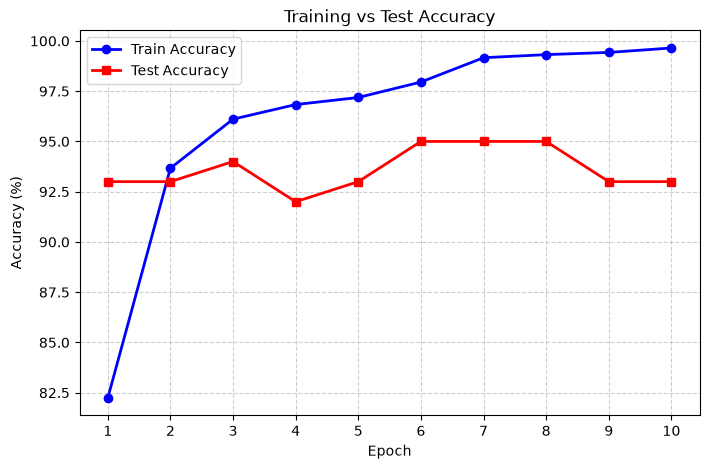

In [8]:
# Plot Accuracy Curves
plt.figure(figsize=(8, 5))

epochs = range(1, epoch_num + 1)

plt.plot(epochs, train_accuracies,
         color='blue',
         marker='o',
         linewidth=2,
         label='Train Accuracy')

plt.plot(epochs, test_accuracies,
         color='red',
         marker='s',
         linewidth=2,
         label='Test Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy")
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [13]:
import os

checkpoint_dir = "./image_cp"

checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")],
    key=lambda x: int(x.split("_")[-1].split(".")[0])   # sort by epoch number
)

for ckpt in checkpoint_files:
    print(f"\n===== {ckpt} =====")
    checkpoint = torch.load(os.path.join(checkpoint_dir, ckpt), map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    image = Image.open("/home/saheb_sub/Desktop/DL/self_test_images/ss/Screenshot From 2026-07-18 11-36-34.png").convert("RGB")
    
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    # Transform and predict
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
        prediction = int(probability > 0.5)

    print("Prediction:", train_dataset.classes[prediction])
    print("Confidence:", probability if prediction == 1 else 1 - probability)

    image = Image.open("/home/saheb_sub/Desktop/DL/self_test_images/ss/Screenshot From 2026-07-18 11-47-36.png").convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    # Transform and predict
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
        prediction = int(probability > 0.5)

    print("Prediction:", train_dataset.classes[prediction])
    print("Confidence:", probability if prediction == 1 else 1 - probability)


===== checkpoint_epoch_5_model_1.pth =====


RuntimeError: Error(s) in loading state_dict for imgClDG:
	Unexpected key(s) in state_dict: "norm1.running_mean", "norm1.running_var", "norm1.num_batches_tracked", "norm2.running_mean", "norm2.running_var", "norm2.num_batches_tracked", "norm3.running_mean", "norm3.running_var", "norm3.num_batches_tracked", "norm5.running_mean", "norm5.running_var", "norm5.num_batches_tracked". 
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 50176]) from checkpoint, the shape in current model is torch.Size([256, 4096]).

----------------------------------------


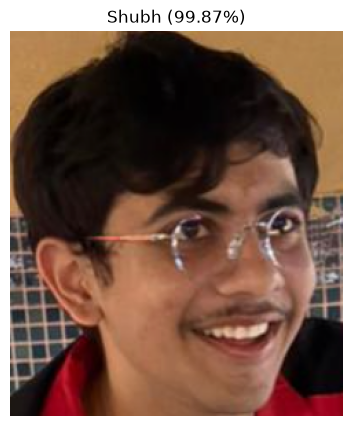

----------------------------------------


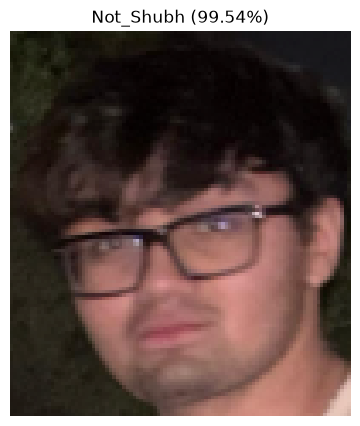

----------------------------------------


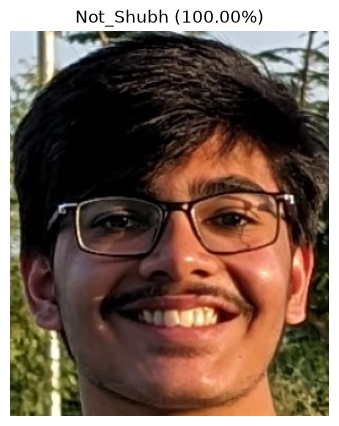

----------------------------------------


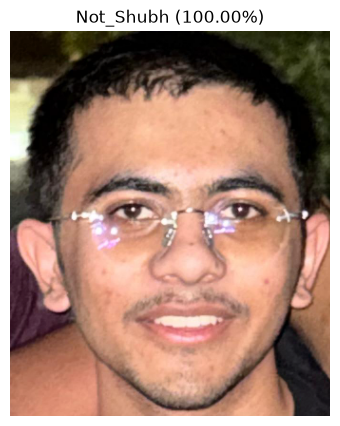

----------------------------------------


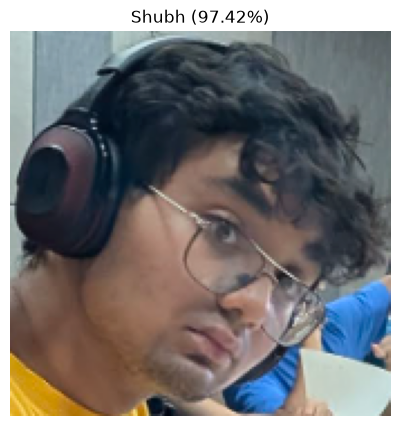

In [9]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image

# Folder containing images
folder_path = "./self_test_images/ss"

# Supported image extensions
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

# Get all image files
image_files = sorted([
    f for f in os.listdir(folder_path)
    if f.lower().endswith(image_extensions)
])

model.eval()

for image_name in image_files:
    image_path = os.path.join(folder_path, image_name)

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        probability = torch.sigmoid(output).item()
        prediction = int(probability > 0.5)

    predicted_class = train_dataset.classes[prediction]
    confidence = probability if prediction == 1 else (1 - probability)

    # Print result
    # print(f"{image_name}")
    # print(f"Prediction : {predicted_class}")
    # print(f"Confidence : {confidence:.4f}")
    print("-" * 40)

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(f"{predicted_class} ({confidence:.2%})")
    plt.axis("off")
    plt.show()

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
# checkpoint_path = "./image_cp/checkpoint_epoch_45_model_1.pth"   # Change to whichever checkpoint you want
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using:", device)
# checkpoint = torch.load(checkpoint_path, map_location=device)

import os

checkpoint_dir = "./image_cp/first_try_CLDG"

checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.endswith(".pth")],
    key=lambda x: int(x.split("_")[-1].split(".")[0])   # sort by epoch number
)

for ckpt in checkpoint_files:
    checkpoint = torch.load(os.path.join(checkpoint_dir, ckpt), map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"\n===== {ckpt} =====")

    # Put your image prediction loop here
    # ---------------- Predict ----------------
    for image_name in image_files:

        image_path = os.path.join(folder_path, image_name)

        image = Image.open(image_path).convert("RGB")
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_tensor)
            probability = torch.sigmoid(output).item()

        prediction = int(probability > 0.5)
        predicted_class = train_dataset.classes[prediction]
        confidence = probability if prediction == 1 else (1 - probability)

        # print(f"{image_name:30} -> {predicted_class:10} ({confidence:.2%})")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.title(f"{predicted_class} ({confidence:.2%})")
        plt.axis("off")
        plt.show()


===== checkpoint_epoch_15_model_1.pth =====


NameError: name 'image_files' is not defined

In [64]:
checkpoint_path = "./image_cp/checkpoint_epoch_10_model_2.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# for image_name in image_files:
checkpoint = torch.load(os.path.join(checkpoint_dir, ckpt), map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
image = Image.open("/home/saheb_sub/Desktop/DL/self_test_images/ss/Screenshot From 2026-07-18 11-36-34.png").convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

# Transform and predict
image_tensor = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()
    prediction = int(probability > 0.5)

print("Prediction:", train_dataset.classes[prediction])
print("Confidence:", probability if prediction == 1 else 1 - probability)

image = Image.open("/home/saheb_sub/Desktop/DL/self_test_images/ss/Screenshot From 2026-07-18 11-47-36.png").convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

# Transform and predict
image_tensor = transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output).item()
    prediction = int(probability > 0.5)

print("Prediction:", train_dataset.classes[prediction])
print("Confidence:", probability if prediction == 1 else 1 - probability)

RuntimeError: Error(s) in loading state_dict for imgClDG:
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 4096]) from checkpoint, the shape in current model is torch.Size([256, 50176]).